In [1]:
##### Creates maps of agricultural capital stock and labor (rasters)

import os
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from glob import glob
import rasterio
from rasterio.warp import reproject, Resampling
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
from pyproj import Transformer

In [2]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import data
capital = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_capital_USD.tif")
capital_p10 = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_capital_USD_p10.tif")
capital_p90 = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_capital_USD_p90.tif")

labor = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_jobs.tif")
labor_p10 = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_jobs_p10.tif")
labor_p90 = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_jobs_p90.tif")

production = rio.open_rasterio(f'{cd}/Data/Clean/Production/total_production_tonnes_2020.tif')

country_boundaries = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/map_capital_labor_raster"

In [37]:
### Data prep

# align crs

crs = "ESRI:54042"

capital = capital.rio.reproject(crs)
capital_p10 = capital_p10.rio.reproject(crs)
capital_p90 = capital_p90.rio.reproject(crs)

labor = labor.rio.reproject(crs)
labor_p10 = labor_p10.rio.reproject(crs)
labor_p90 = labor_p90.rio.reproject(crs)

production = production.rio.reproject(crs)

country_boundaries = country_boundaries.to_crs(crs)

# convert to million 
capital_thousand = capital / 1e3
capital_thousand_p10 = capital_p10 / 1e3
capital_thousand_p90 = capital_p90 / 1e3

labor_thousand = labor / 1e3
labor_thousand_p10 = labor_p10 / 1e3
labor_thousand_p90 = labor_p90 / 1e3

# calculate % differnce 
capital_thousand_p10_percent_diff = (capital_thousand_p10 - capital_thousand) / capital_thousand
capital_thousand_p90_percent_diff = (capital_thousand_p90 - capital_thousand) / capital_thousand

labor_thousand_p10_percent_diff = (labor_thousand_p10 - labor_thousand) / labor_thousand
labor_thousand_p90_percent_diff = (labor_thousand_p90 - labor_thousand) / labor_thousand

# calculate intensities
capital_intensity_USD_per_tonne = capital / production
labor_intensity_thousand_jobs_per_tonne = (labor / production) * 1e3

In [39]:
values = capital_thousand.values.flatten()

# drop NaNs (rasters typically have nodata pixels, e.g. ocean/non-agricultural areas)
values_clean = values[~np.isnan(values)]

# further restrict to values strictly above 0
values_clean = values_clean[values_clean > 0]

print(f"Total pixels: {len(values)}")
print(f"Valid (non-NaN, >0) pixels: {len(values_clean)}")

# pull every 10th percentile: 10, 20, 30, ..., 100
percentiles = np.arange(10, 101, 10)
percentile_values = np.percentile(values_clean, percentiles)

for p, v in zip(percentiles, percentile_values):
    print(f"{p}th percentile: {v:.2f}")

Total pixels: 27159875
Valid (non-NaN, >0) pixels: 5258135
10th percentile: 3.07
20th percentile: 12.20
30th percentile: 35.35
40th percentile: 71.38
50th percentile: 168.47
60th percentile: 385.45
70th percentile: 890.04
80th percentile: 2419.17
90th percentile: 8071.45
100th percentile: 821898.44


In [ ]:
# # otal pixels: 27159875
# Valid (non-NaN) pixels: 6689423
# 10th percentile: 0.00
# 20th percentile: 0.00
# 30th percentile: 3.67
# 40th percentile: 20.84
# 50th percentile: 52.67
# 60th percentile: 156.42
# 70th percentile: 444.66
# 80th percentile: 1386.12
# 90th percentile: 5674.18
# 100th percentile: 821898.44

#### Map capital

In [ ]:
##### Produce global map of capital (mean estimate) 

# Prepare raster
value_plot = capital_thousand.squeeze()

# Define bin ranges (chosen to highlight concentration)
data_max = np.nanmax(value_plot.values)
cap = data_max 
bounds = [0, 1, 100, 500, 1000, 5000, 10000, 50000, 100000, 200000, cap] 
labels = ['0', '1-100k', '100-500k', '500k-1M', '1-5M', '5-10M', '10-50M', '50-100M', '100-200M', '200M+']

n_bins = len(bounds) - 1
cmap = plt.get_cmap("turbo", n_bins)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=1
)

im = value_plot.plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    add_colorbar=False,
    add_labels=False,
    zorder=2
)

# Clip to country_boundaries
minx, miny, maxx, maxy = country_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Agricultural Capital Stock", fontsize=16, weight='bold', pad=20)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01,
    shrink=0.5,
    boundaries=bounds,
    ticks=[(bounds[i] + bounds[i+1]) / 2 for i in range(len(bounds) - 1)]
)
cbar.ax.set_yticklabels(labels)
cbar.set_label("USD", fontsize=10)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/capital_stock.png", dpi=300, bbox_inches='tight')

#### Map intensities

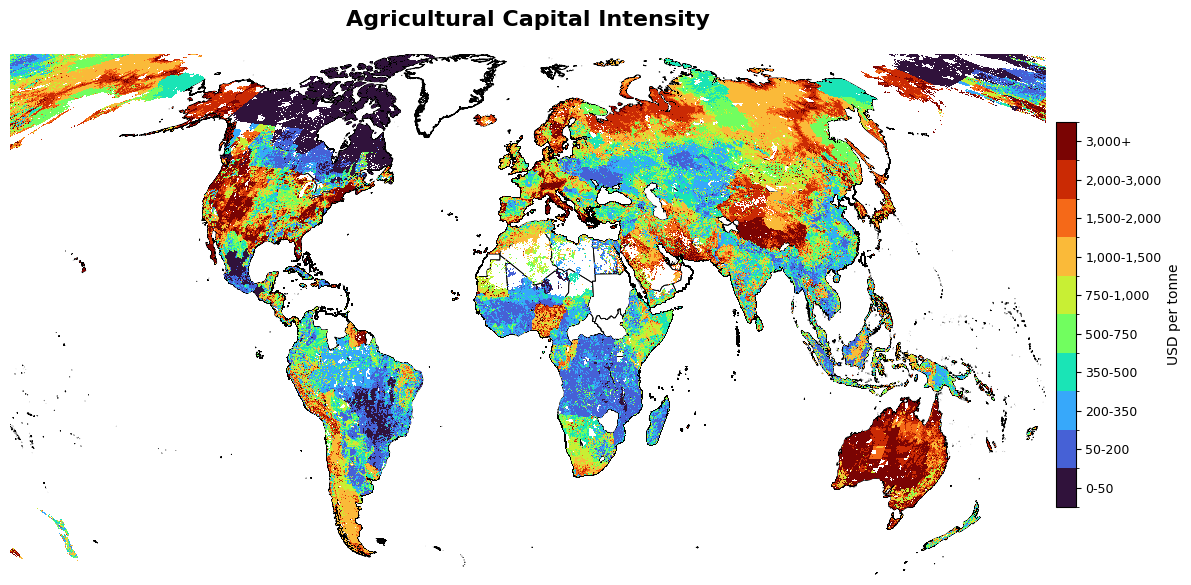

In [32]:
##### Produce global map of capital intensity 

# Prepare raster
value_plot = capital_intensity_USD_per_tonne.squeeze()

# Define bin ranges (roughly deciles)
data_max = np.nanmax(value_plot.values)
cap = data_max 
bounds = [0, 50, 200, 350, 500, 750, 1000, 1500, 2000, 3000, cap] 
labels = ['0-50', '50-200', '200-350', '350-500', '500-750', '750-1,000', '1,000-1,500', '1,500-2,000', '2,000-3,000', '3,000+']

n_bins = len(bounds) - 1
cmap = plt.get_cmap("turbo", n_bins)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=1
)

im = value_plot.plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    add_colorbar=False,
    add_labels=False,
    zorder=2
)

# Clip to country_boundaries
minx, miny, maxx, maxy = country_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Agricultural Capital Intensity", fontsize=16, weight='bold', pad=20)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01,
    shrink=0.5,
    boundaries=bounds,
    ticks=[(bounds[i] + bounds[i+1]) / 2 for i in range(len(bounds) - 1)]
)
cbar.ax.set_yticklabels(labels)
cbar.set_label("USD per tonne", fontsize=10)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/capital_intensity.png", dpi=300, bbox_inches='tight')

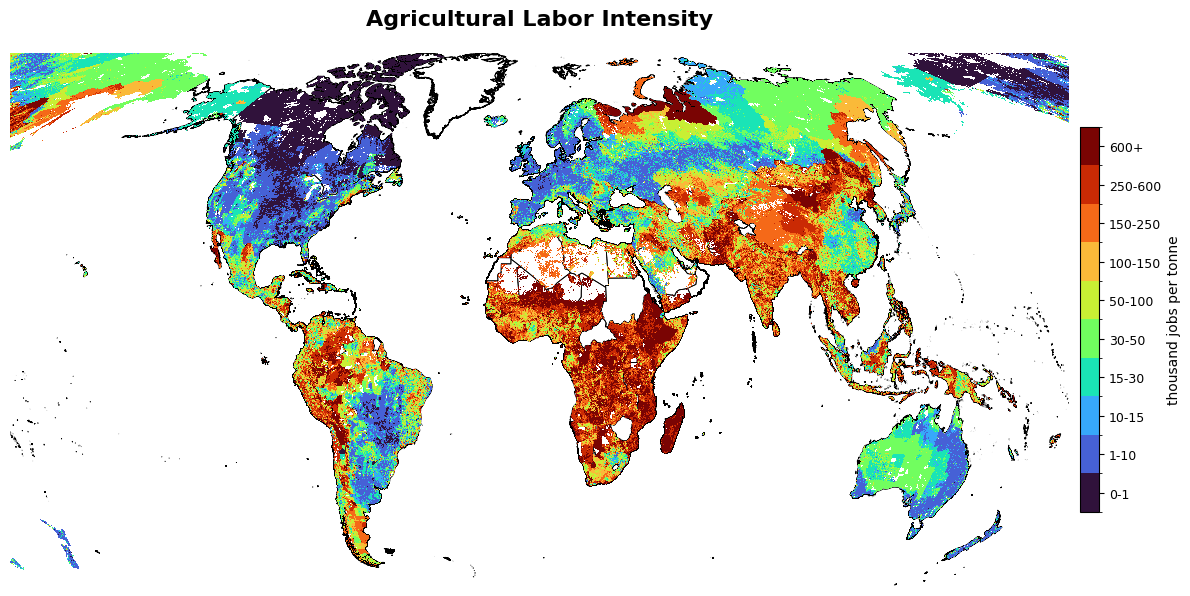

In [33]:
##### Produce global map of labor intensity 

# Prepare raster
value_plot = labor_intensity_thousand_jobs_per_tonne.squeeze()

# Define bin ranges (roughly deciles)
data_max = np.nanmax(value_plot.values)
cap = data_max 
bounds = [0, 1, 10, 15, 30, 50, 100, 150, 250, 600, cap] 
labels = ['0-1', '1-10', '10-15', '15-30', '30-50', '50-100', '100-150', '150-250', '250-600', '600+']

n_bins = len(bounds) - 1
cmap = plt.get_cmap("turbo", n_bins)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=1
)

im = value_plot.plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    add_colorbar=False,
    add_labels=False,
    zorder=2
)

# Clip to country_boundaries
minx, miny, maxx, maxy = country_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Agricultural Labor Intensity", fontsize=16, weight='bold', pad=20)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01,
    shrink=0.5,
    boundaries=bounds,
    ticks=[(bounds[i] + bounds[i+1]) / 2 for i in range(len(bounds) - 1)]
)
cbar.ax.set_yticklabels(labels)
cbar.set_label("thousand jobs per tonne", fontsize=10)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/labor_intensity.png", dpi=300, bbox_inches='tight')

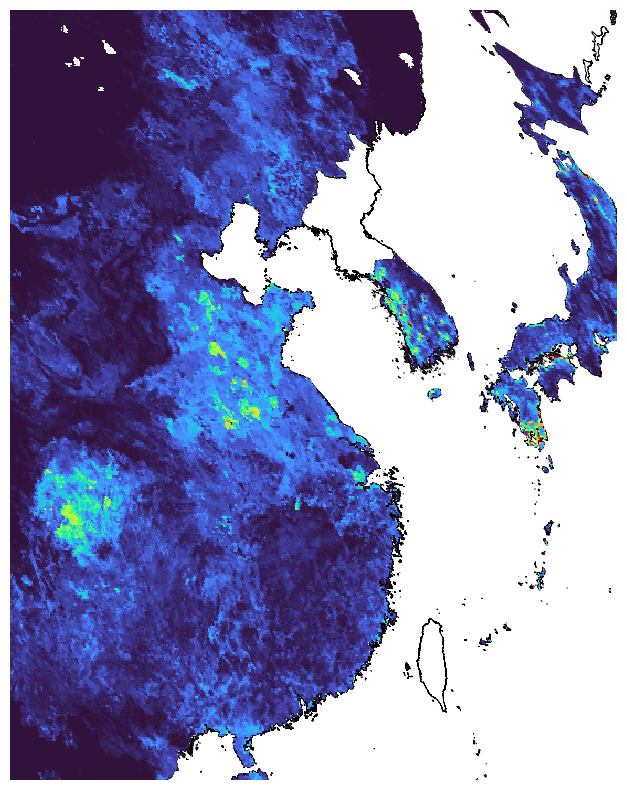

In [11]:
##### Produce regional map of capital stock

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Country borders underneath
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=1
)

# Raster on top
im = capital_plot.plot(
    ax=ax,
    cmap="turbo",
    vmin=0.1,
    vmax=250,
    add_colorbar=False,
    add_labels=False,
    zorder=2
)

transformer = Transformer.from_crs("EPSG:4326", "ESRI:54042", always_xy=True)

# Set bbox for region of interest 

# # Europe
# minx, miny = transformer.transform(-15.108776, 41.834654)
# maxx, maxy = transformer.transform(31.868763, 59.016438)

# # Egypt & the Levant 
# minx, miny = transformer.transform(23.819561, 21.459939)
# maxx, maxy = transformer.transform(40.167217, 36.037301)

# # Colombia & Venezuela
# minx, miny = transformer.transform(-80.024414,-2.108899)
# maxx, maxy = transformer.transform(-59.677734,13.923404)

# China and East Asia 
minx, miny = transformer.transform(98.026886,20.106878)
maxx, maxy = transformer.transform(150.409698,46.049884)

# # East Africa
# minx, miny = transformer.transform(27.421875,-5.747174)
# maxx, maxy = transformer.transform(43.637695,5.353521)

# # Continental US
# minx, miny = transformer.transform(-130.609589,20.777383)
# maxx, maxy = transformer.transform(-66.976776,49.675182)

# Rest
ax.set_xlim([minx, maxx])
ax.set_ylim([miny, maxy])   

ax.set_axis_off()

plt.tight_layout()
plt.show()